# 手書き数字の分類：CNNの条件比較

MNISTを用いて、Convolutional Neural Network（畳み込みニューラルネットワーク；CNN）を学習します。

このNotebookの目的は、正解率を競うことだけではありません。**基準条件から原則として一度に一つの条件だけを変更し、その影響を同じ評価方法で比較すること**が目的です。

## データの役割

- 学習データ：モデルのパラメータを学習する
- 検証データ：ネットワーク構造や学習条件を比較する
- テストデータ：採用する条件を決めた後、最後に一度だけ評価する

GPUは必須ではありません。Google Colabで利用可能な場合は、ランタイム設定からGPUを選択できます。

## 1. ライブラリと乱数シード

In [1]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


## 2. MNISTの読み込みと確認

MNISTは、0～9の手書き数字を表す28×28画素のグレースケール画像と正解ラベルからなるデータセットです。

In [2]:
(x_train_all, y_train_all), (x_test, y_test) = keras.datasets.mnist.load_data()

# 元の学習データ60,000枚を、学習50,000枚と検証10,000枚に分ける
x_train, y_train = x_train_all[:50000], y_train_all[:50000]
x_val, y_val = x_train_all[50000:], y_train_all[50000:]

print("学習:", x_train.shape, y_train.shape)
print("検証:", x_val.shape, y_val.shape)
print("テスト:", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
学習: (50000, 28, 28) (50000,)
検証: (10000, 28, 28) (10000,)
テスト: (10000, 28, 28) (10000,)


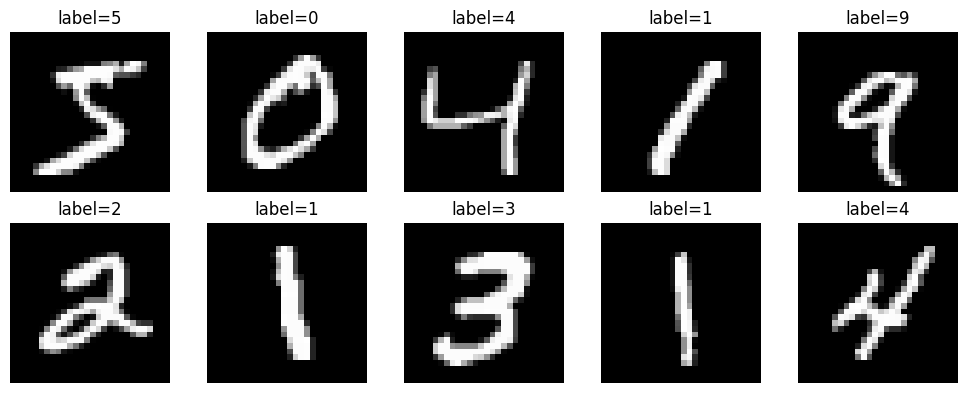

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"label={y_train[i]}")
    ax.axis("off")
plt.tight_layout()

## 3. 前処理

画素値を0～255の整数から0～1の実数に変換し、CNNへの入力となるチャネル次元を追加します。

In [4]:
def preprocess(x):
    x = x.astype("float32") / 255.0
    return np.expand_dims(x, axis=-1)

x_train = preprocess(x_train)
x_val = preprocess(x_val)
x_test = preprocess(x_test)

print(x_train.shape, x_train.min(), x_train.max())

(50000, 28, 28, 1) 0.0 1.0


## 4. 実験条件

最初は基準条件のまま実行してください。その後、下の値を**原則として一つだけ**変更し、別の実験として再実行します。

変更候補：`FILTERS_1`、`FILTERS_2`、`DROPOUT_RATE`、`EPOCHS`、`BATCH_SIZE`、`TRAIN_SIZE`

比較表には、変更前後の条件、検証精度、学習時間を記録してください。

In [5]:
# ===== 実験ごとに記録する設定 =====
EXPERIMENT_NAME = "baseline"
FILTERS_1 = 16
FILTERS_2 = 32
DROPOUT_RATE = 0.30
EPOCHS = 5
BATCH_SIZE = 128
TRAIN_SIZE = 50000

assert 1000 <= TRAIN_SIZE <= len(x_train)
print({
    "name": EXPERIMENT_NAME,
    "filters": (FILTERS_1, FILTERS_2),
    "dropout": DROPOUT_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "train_size": TRAIN_SIZE,
})

{'name': 'baseline', 'filters': (16, 32), 'dropout': 0.3, 'epochs': 5, 'batch_size': 128, 'train_size': 50000}


## 5. 基準CNNの構築

In [6]:
def build_model(filters_1=16, filters_2=32, dropout_rate=0.30):
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(filters_1, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(filters_2, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
model = build_model(FILTERS_1, FILTERS_2, DROPOUT_RATE)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        15,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,490 (80.04 KB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. 学習

In [7]:
start = time.perf_counter()
history = model.fit(
    x_train[:TRAIN_SIZE], y_train[:TRAIN_SIZE],
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)
training_time = time.perf_counter() - start
best_val_accuracy = max(history.history["val_accuracy"])

print(f"学習時間: {training_time:.1f} 秒")
print(f"検証精度の最大値: {best_val_accuracy:.4f}")

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.8665 - loss: 0.4478 - val_accuracy: 0.9656 - val_loss: 0.1217
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.9619 - loss: 0.1271 - val_accuracy: 0.9803 - val_loss: 0.0768
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9724 - loss: 0.0920 - val_accuracy: 0.9824 - val_loss: 0.0628
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9765 - loss: 0.0770 - val_accuracy: 0.9841 - val_loss: 0.0575
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9788 - loss: 0.0679 - val_accuracy: 0.9852 - val_loss: 0.0503
学習時間: 95.6 秒
検証精度の最大値: 0.9852


## 7. 学習曲線

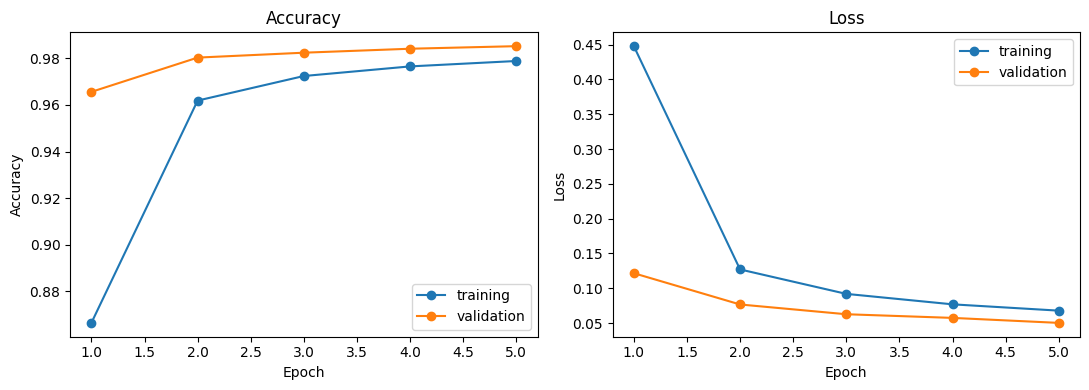

In [8]:
epochs = range(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(epochs, history.history["accuracy"], marker="o", label="training")
axes[0].plot(epochs, history.history["val_accuracy"], marker="o", label="validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history.history["loss"], marker="o", label="training")
axes[1].plot(epochs, history.history["val_loss"], marker="o", label="validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()

## 8. 実験結果を記録する

条件を変更する前に、このセルの出力を表へ転記してください。複数の条件を比較した後、どの条件を最終候補にするかを検証データの結果から決めます。

In [9]:
result = {
    "experiment": EXPERIMENT_NAME,
    "filters_1": FILTERS_1,
    "filters_2": FILTERS_2,
    "dropout": DROPOUT_RATE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "train_size": TRAIN_SIZE,
    "best_validation_accuracy": round(float(best_val_accuracy), 4),
    "training_time_sec": round(training_time, 1),
}
result

{'experiment': 'baseline',
 'filters_1': 16,
 'filters_2': 32,
 'dropout': 0.3,
 'epochs': 5,
 'batch_size': 128,
 'train_size': 50000,
 'best_validation_accuracy': 0.9852,
 'training_time_sec': 95.6}

## 9. 最終候補のテストデータ評価

**注意：このセルは、検証データによる条件比較を終え、採用する条件を決めた後に実行してください。**

テスト結果を見てから条件を再調整すると、テストデータが最終評価用ではなくなります。

In [10]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"テスト精度: {test_accuracy:.4f}")
print(f"テスト損失: {test_loss:.4f}")

テスト精度: 0.9861
テスト損失: 0.0403


## 10. 誤分類例を確認する

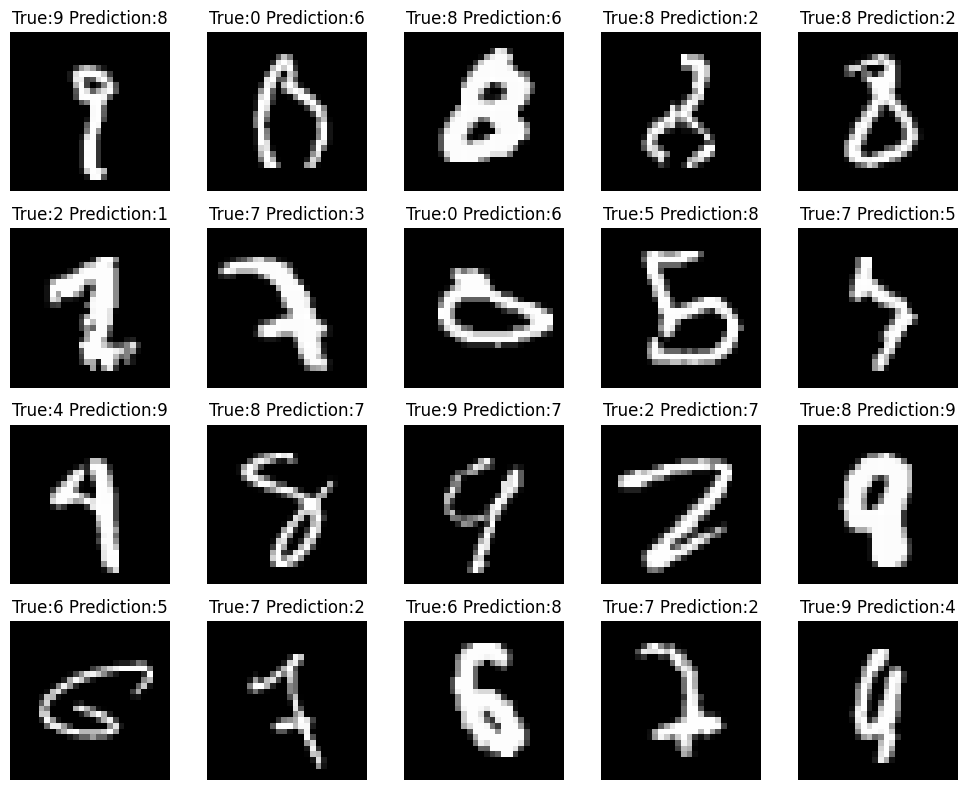

In [12]:
probabilities = model.predict(x_test, verbose=0)
predictions = np.argmax(probabilities, axis=1)
wrong_indices = np.where(predictions != y_test)[0]

n_show = min(20, len(wrong_indices))
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for ax, idx in zip(axes.ravel(), wrong_indices[:n_show]):
    ax.imshow(x_test[idx].squeeze(), cmap="gray")
    ax.set_title(f"True:{y_test[idx]} Prediction:{predictions[idx]}")
    ax.axis("off")
for ax in axes.ravel()[n_show:]:
    ax.axis("off")
plt.tight_layout()

## 11. 発表で示す内容

1. 基準CNNの構造と、学習・検証・テストの画像数
2. 変更した条件と、その条件を選んだ理由
3. 基準条件と変更条件の検証精度・学習時間の比較
4. 学習曲線から読み取れること
5. 代表的な誤分類例と、間違いの特徴
6. 結果から言えることと、今回の実験だけでは言えないこと

### 考察の確認

- 比較した条件以外は同じだったか
- 1回だけの偶然を一般的な結論としていないか
- 精度だけでなく、学習時間や過学習も確認したか
- 「なぜその結果になったと考えるか」を、得られた結果と結び付けて説明したか